This is the final technical stage. We will train an XGBoost model and use SHAP (SHapley Additive exPlanations) to interpret the results.

Environment Setup

We need to install the libraries for the Gradient Boosting model and the explainability framework.

In [1]:
%pip install xgboost shap

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 2.1 MB/s eta 0:00:49
   ---------------------------------------- 1.0/101.7 MB 1.8 MB/s eta 0:00:55
    --------------------------------------- 1.3/101.7 MB 1.9 MB/s eta 0:00:55
    --------------------------------------- 1.6/101.7 MB 1.8 MB/s eta 0:00:57
    --------------------------------------- 1.8/101.7 MB 1.7 MB/s eta 0:01:00
    --------------------------------------- 2.1/101.7 MB 1.6 MB/s eta 0:01:04
    --------------------------------------- 2.4/101.7 MB 1.5 MB/s eta 0:01:07
   - -------------------------------------- 2.6/101.7 MB 1.5 MB/s eta 0:01:09
   - -------------------------------------- 2.9/101.7 MB 1.4 MB/s eta 0:01:12
   - -------------------------------------- 2.9/101.7 MB 1.4 MB/s eta 0:01:12
   - -------------------------------------- 3.1/101.7 MB 1.3 MB/s eta 0:01:17



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load augmented data
df = pd.read_csv(r'../data/processed/augmented_data.csv')

# Drop non-numeric categorical columns for XGBoost if they haven't been encoded
# Or convert them to 'category' type which XGBoost can handle natively
for col in ['year_level', 'program', 'mode_of_study']:
    df[col] = df[col].astype('category')

X = df.drop(columns=['target_satisfaction'])
y = df['target_satisfaction']

# Map target_satisfaction (2,3,4,5) to (0,1,2,3) because XGBoost expects 0-indexed labels
y = y - 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

c:\Users\SHANIA\Downloads\SOIT-Predictive-Analytics-1\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model Training (XGBoost)

We use XGBoost because it is highly effective at finding non-linear patterns in tabular data, which our correlation heatmap suggested is necessary.

In [3]:
# Initialize and train the model
model = xgb.XGBClassifier(
    enable_categorical=True, 
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=42
)

model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.74

Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       0.86      0.86      0.86         7
           2       0.71      0.62      0.67         8
           3       0.50      0.50      0.50         8

    accuracy                           0.74        31
   macro avg       0.74      0.75      0.74        31
weighted avg       0.74      0.74      0.74        31



Explainable AI (SHAP Values)

This is the intended novelty for the paper.  we want to explain  why the model made its decision and not just predicted such values.

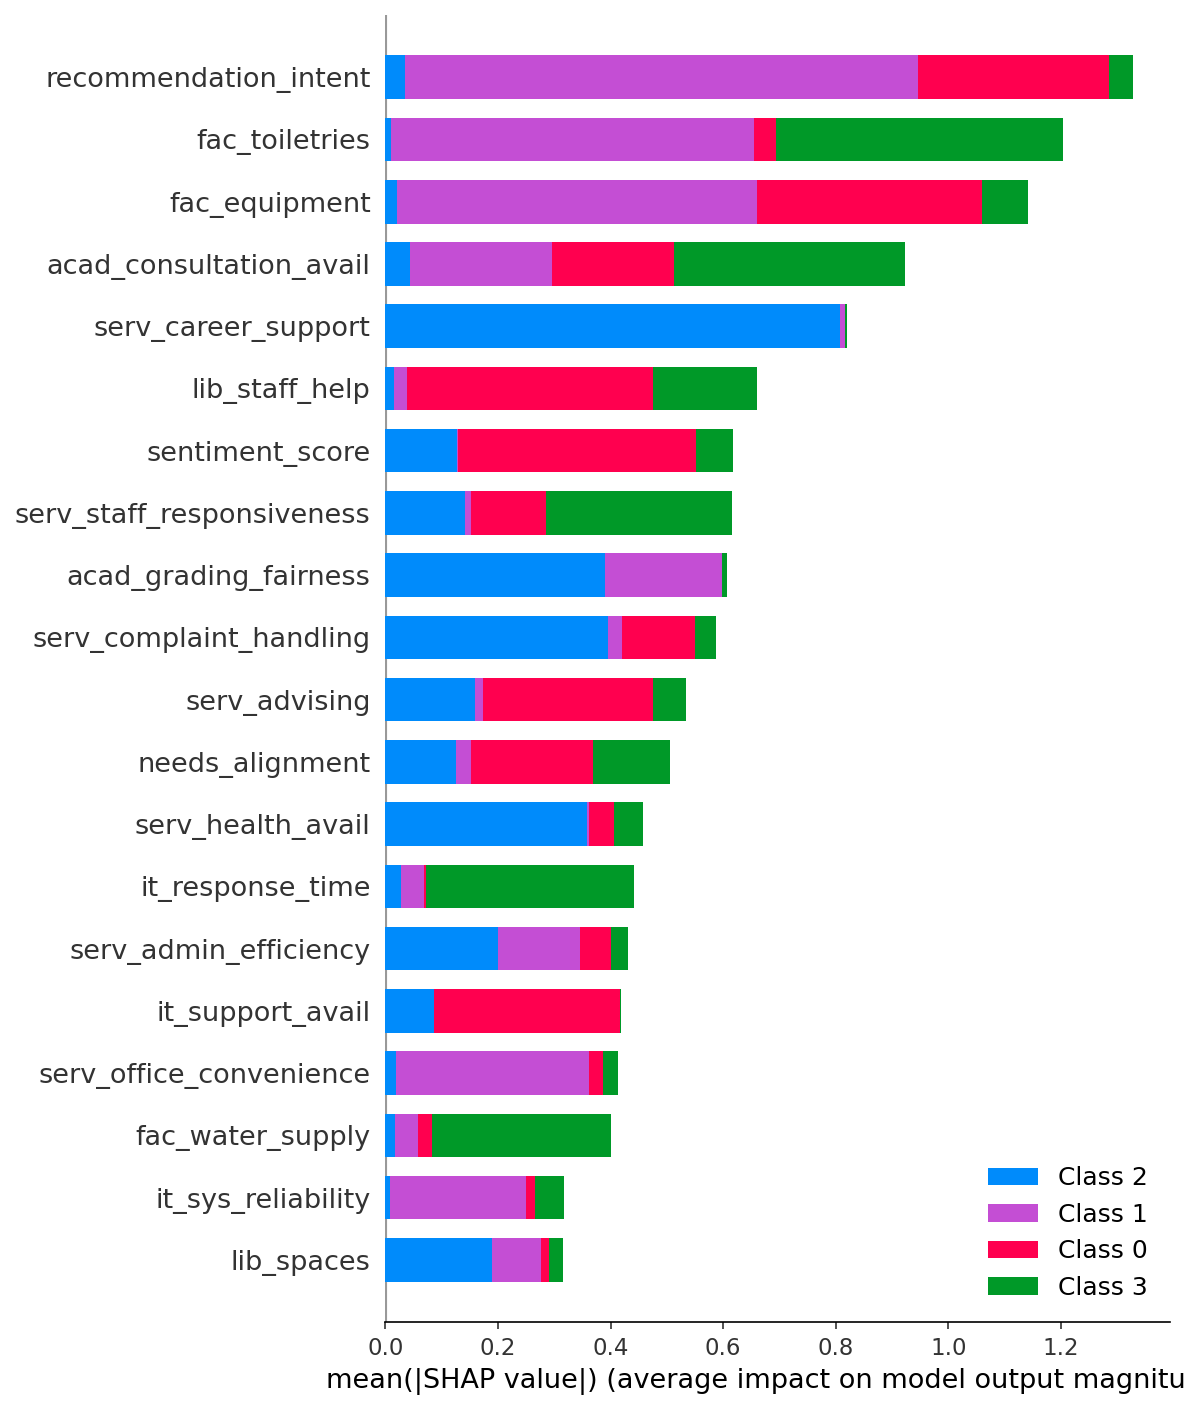

In [6]:
# Initialize SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary Plot: Shows the top predictors of satisfaction
plt.figure(figsize=(10, 6), dpi=150)
shap.summary_plot(shap_values, X_test, plot_type="bar")
plt.show()

Confusion Matrix Visualization

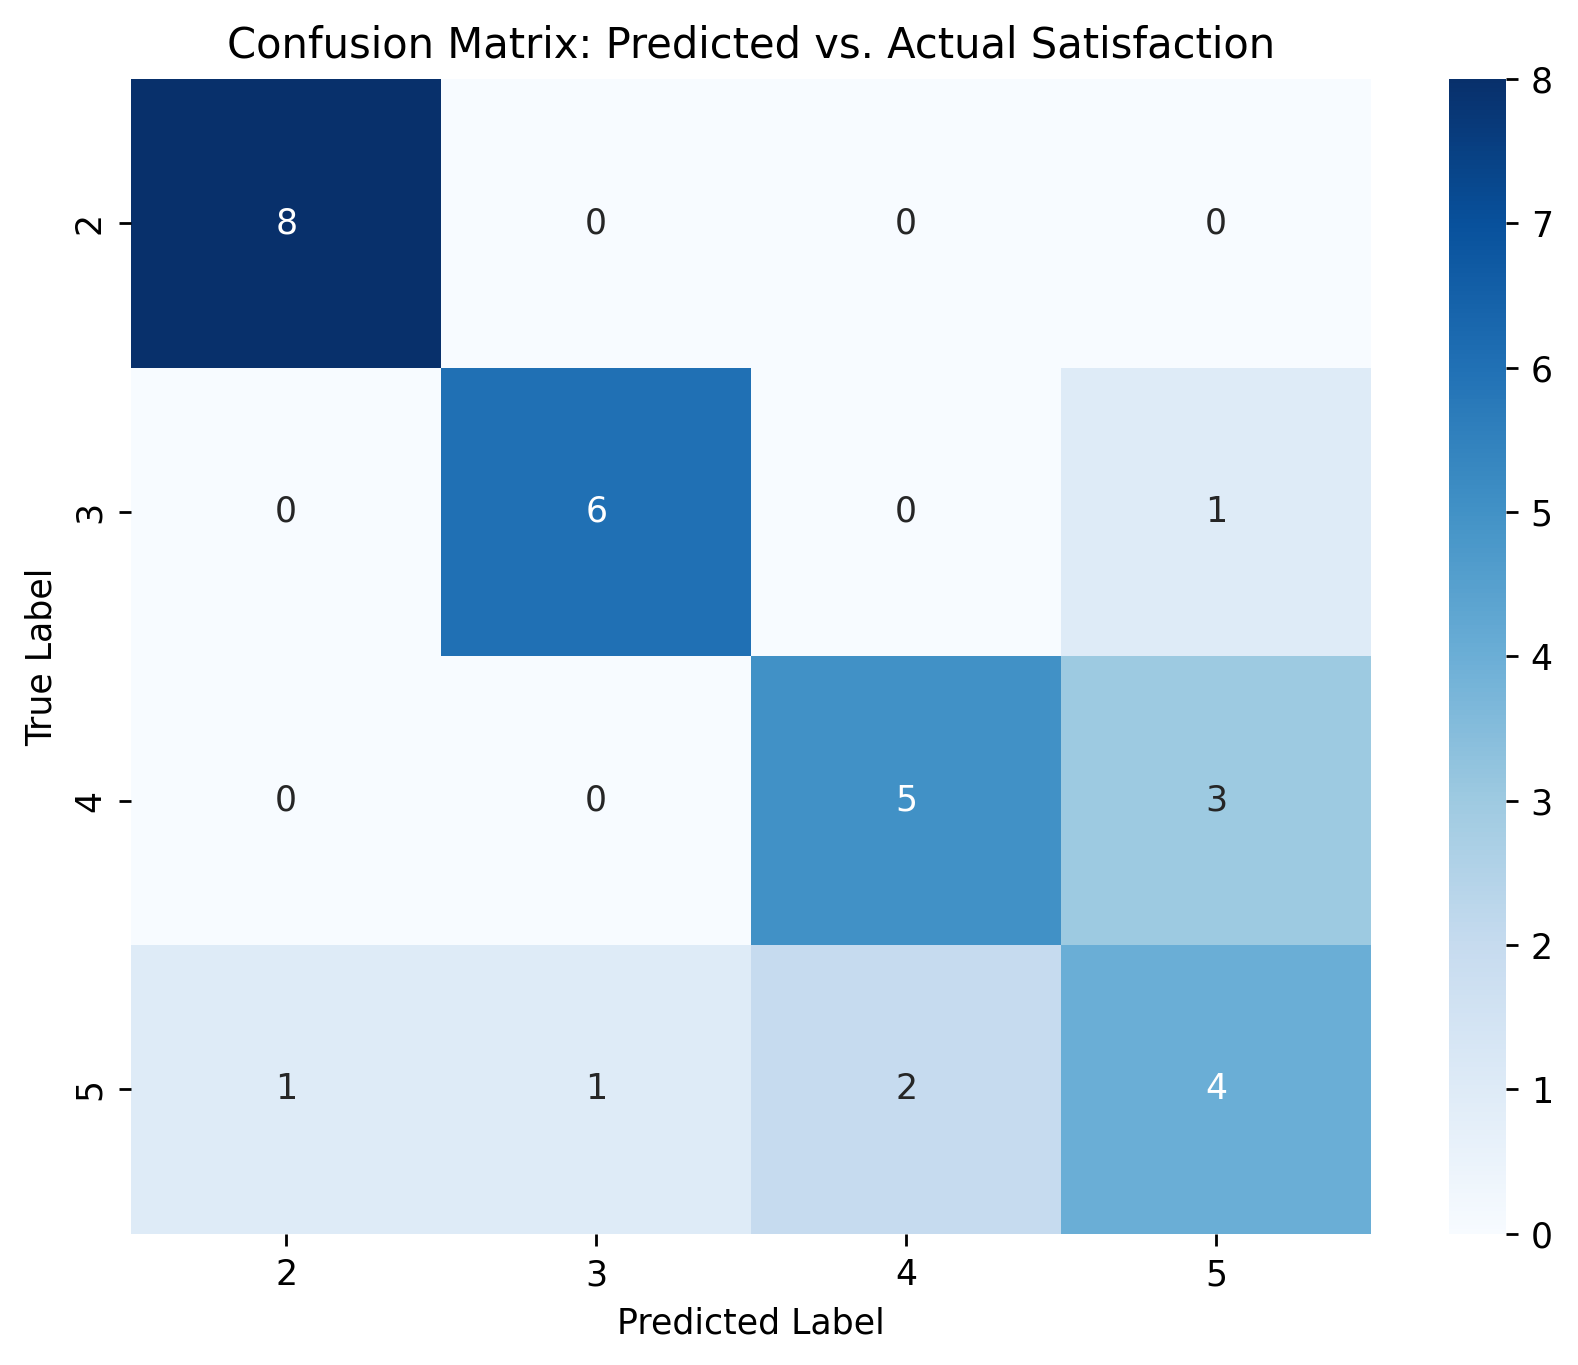

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6), dpi=250)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[2,3,4,5], yticklabels=[2,3,4,5])
plt.title('Confusion Matrix: Predicted vs. Actual Satisfaction')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()